In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [ ]:
#optional (if doesn't work, just upload directly into colab session)
!pip install -q kaggle

from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d mrgeislinger/bart-ridership
!unzip -o bart-ridership.zip

Saving date-hour-soo-dest-2019.csv to date-hour-soo-dest-2019.csv
Saving date-hour-soo-dest-2022.csv to date-hour-soo-dest-2022.csv
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mrgeislinger/bart-ridership
License(s): Attribution 4.0 International (CC BY 4.0)
100% 394M/394M [00:07<00:00, 53.3MB/s]

Archive:  bart-ridership.zip
  inflating: README.txt              
  inflating: ridership/date-hour-soo-dest-2011.csv  
  inflating: ridership/date-hour-soo-dest-2012.csv  
  inflating: ridership/date-hour-soo-dest-2013.csv  
  inflating: ridership/date-hour-soo-dest-2014.csv  
  inflating: ridership/date-hour-soo-dest-2015.csv  
  inflating: ridership/date-hour-soo-dest-2016.csv  
  inflating: ridership/date-hour-soo-dest-2017.csv  
  inflating: ridership/date-hour-soo-dest-2018.csv  
  inflating: ridership/date-hour-soo-dest-2019.csv  
  inflating: ridership/d

In [13]:
df_2019 = pd.read_csv('/date-hour-soo-dest-2019.csv')
df_2019['Era'] = 'Pre-COVID (2019)'

df_2022 = pd.read_csv('/date-hour-soo-dest-2022.csv')
df_2022['Era'] = 'Post-COVID (2022)'

df = pd.concat([df_2019, df_2022], ignore_index=True)
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = pd.Categorical(df['Date'].dt.day_name(), categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

In [15]:
top_stations =['EMBR', 'MONT', 'POWL', 'CIVC']
df_top = df[df['Origin Station'].isin(top_stations)].copy()

df_grouped = df_top.groupby(['Date', 'Hour', 'Origin Station', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

era_palette = {'Pre-COVID (2019)': '#4C72B0', 'Post-COVID (2022)': '#DD8452'}

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


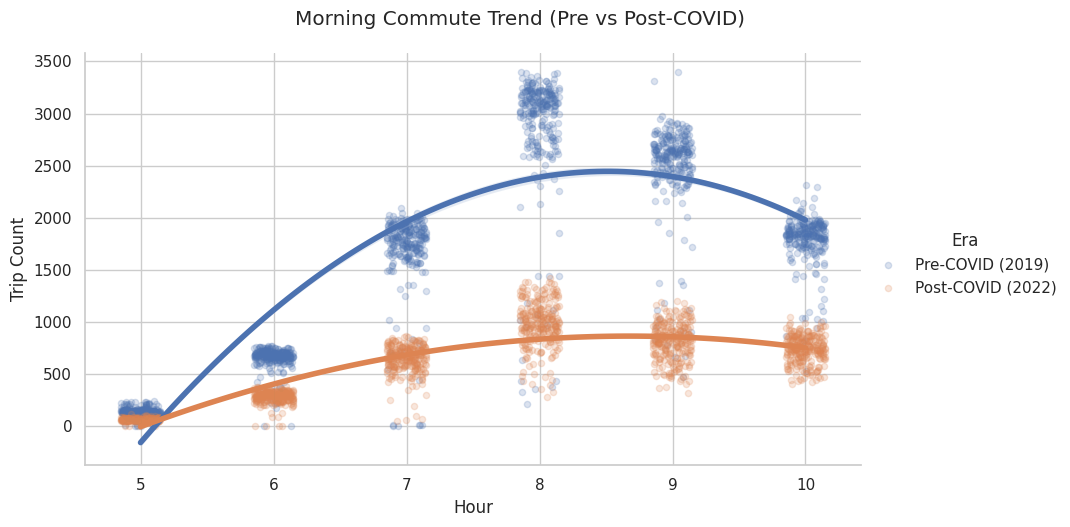

In [16]:
morning = df_top.groupby(['Date', 'Hour', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

morning = morning[(morning['Hour'] >= 5) & (morning['Hour'] <= 10) & (~morning['Day'].isin(['Saturday', 'Sunday']))]

sns.set_theme(style="whitegrid")
lm = sns.lmplot(
    data=morning,
    x="Hour",
    y="Trip Count",
    hue="Era",
    order=2,
    palette=era_palette,
    x_jitter=0.15,
    scatter_kws={'alpha': 0.2, 's': 20},
    line_kws={'linewidth': 4},
    height=5,
    aspect=1.8,
    legend_out=True
)
lm.fig.suptitle("Morning Commute Trend (Pre vs Post-COVID)", y=1.05)
plt.show()

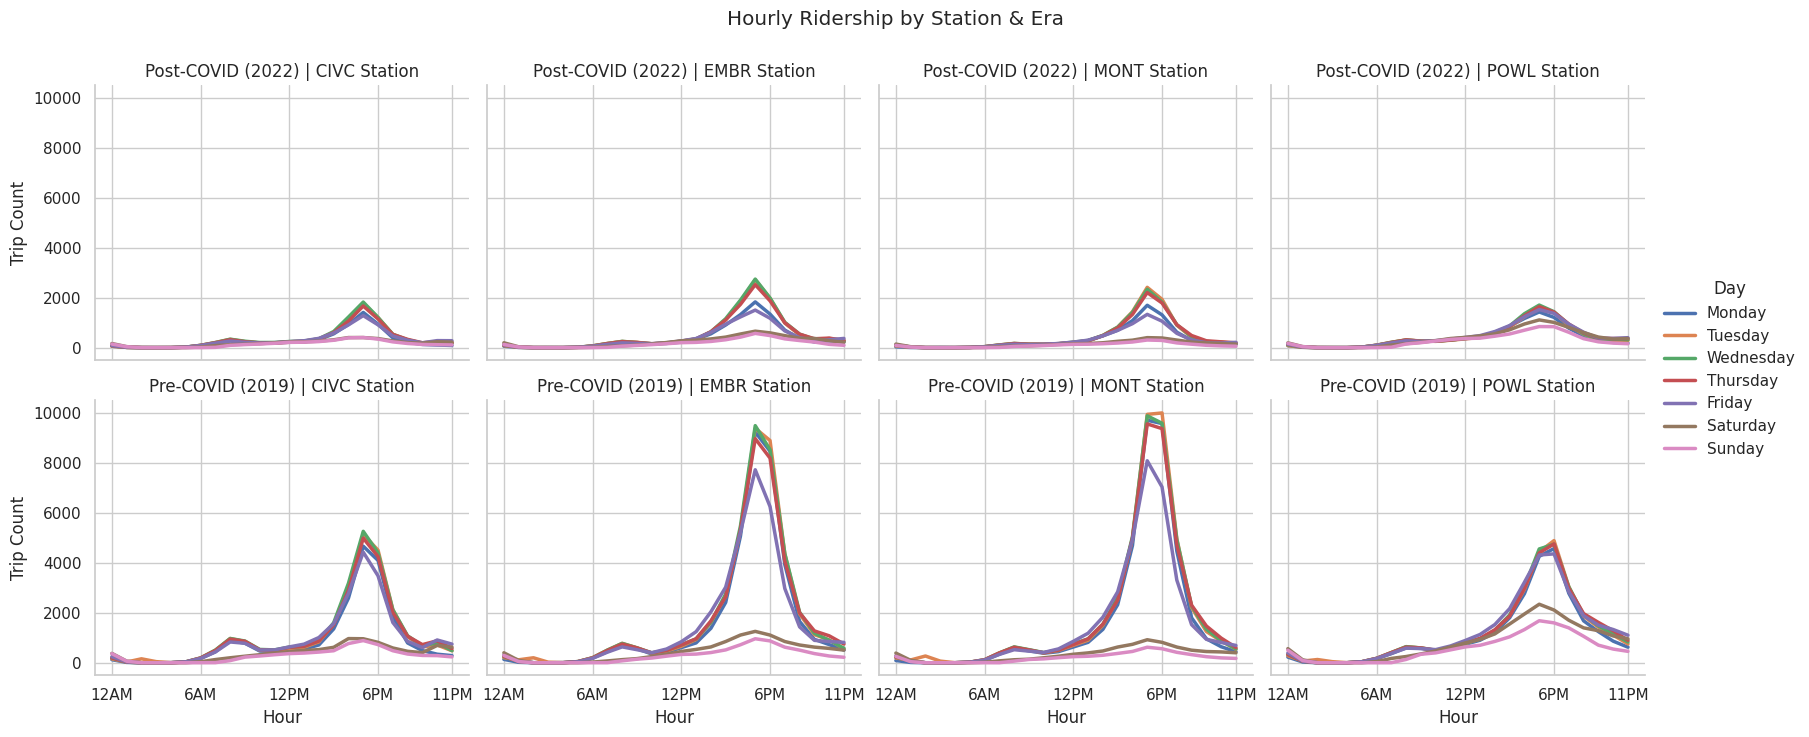

In [17]:
hourly_avg = df_grouped.groupby(['Hour', 'Origin Station', 'Day', 'Era'], observed=True)['Trip Count'].mean().reset_index()

rel = sns.relplot(
    data=hourly_avg,
    x="Hour", y="Trip Count",
    hue="Day",
    col="Origin Station", row="Era",
    kind="line",
    height=3.5, aspect=1.2,
    linewidth=2.5,
    facet_kws={'sharey': True}
)
rel.set_titles("{row_name} | {col_name} Station")
rel.fig.suptitle("Hourly Ridership by Station & Era", y=1.05)
for ax in rel.axes.flat:
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.set_xticklabels(['12AM', '6AM', '12PM', '6PM', '11PM'])
plt.show()

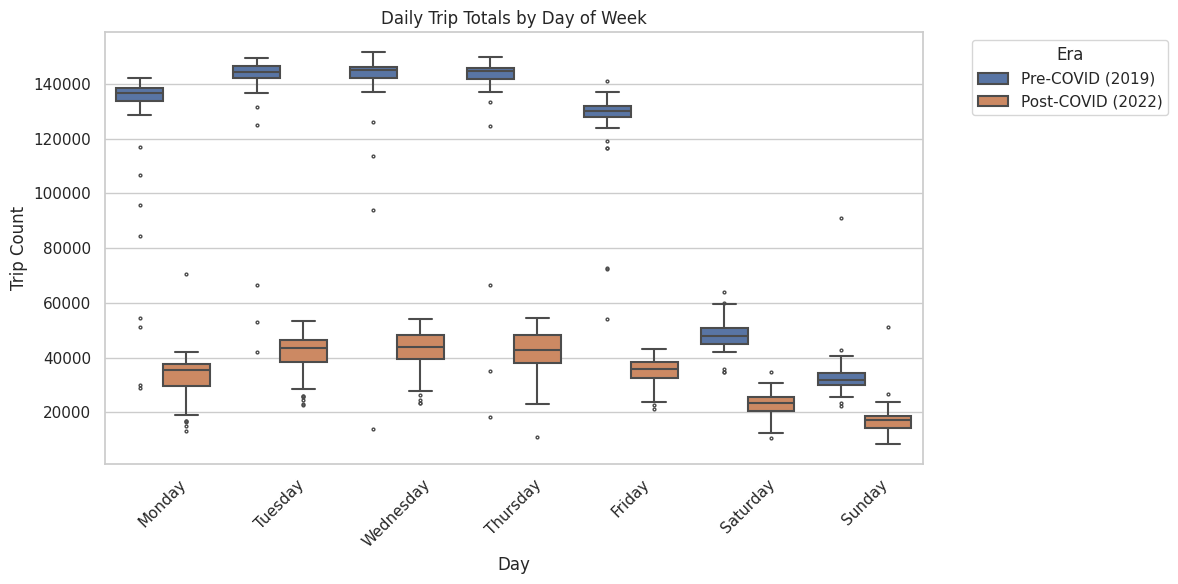

In [ ]:
daily_totals = df_top.groupby(['Date', 'Day', 'Era'], observed=True)['Trip Count'].sum().reset_index()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=daily_totals,
    x="Day", y="Trip Count",
    hue="Era",
    palette=era_palette,
    fliersize=2, linewidth=1.5
)
ax.set_title("Daily Trip Totals by Day of Week")
plt.xticks(rotation=45)
plt.legend(title='Era', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()